In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_parquet("../data/features_with_target.parquet")
print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
df.head()

Shape: (486380, 21)

Columns: ['date', 'ticker', 'close', 'return_1d', 'return_5d', 'return_21d', 'return_63d', 'return_252d', 'sma_20', 'sma_50', 'sma_200', 'price_vs_sma20', 'price_vs_sma50', 'price_vs_sma200', 'volatility_21d', 'volatility_63d', 'rsi_14', 'bb_position', 'volume_ratio_20d', 'forward_return_21d', 'target']


,date,ticker,close,return_1d,return_5d,return_21d,return_63d,return_252d,sma_20,sma_50,...,price_vs_sma20,price_vs_sma50,price_vs_sma200,volatility_21d,volatility_63d,rsi_14,bb_position,volume_ratio_20d,forward_return_21d,target
0,2020-12-31,A,114.066994,0.009370,0.010145,0.027132,0.172729,0.387500,112.833347,108.234182,...,0.010933,0.053891,0.246489,0.162125,0.231044,48.283169,0.719896,0.815608,0.041371,0
1,2021-01-04,A,114.398712,0.002908,0.012996,0.037222,0.190369,0.414242,113.086268,108.503817,...,0.011606,0.054329,0.246606,0.159428,0.229133,51.899192,0.778646,1.246826,0.029585,0
2,2021-01-05,A,115.334053,0.008176,0.016771,0.054817,0.161813,0.421602,113.310386,108.754808,...,0.017859,0.060496,0.253264,0.156176,0.221129,67.896829,0.937569,1.386990,0.037288,0
3,2021-01-06,A,118.496773,0.027422,0.050000,0.068967,0.211173,0.456122,113.728741,109.080606,...,0.041925,0.086323,0.283594,0.174527,0.223940,75.449550,1.335430,1.422188,0.002360,0
4,2021-01-07,A,121.649895,0.026609,0.076471,0.104606,0.216470,0.480254,114.179122,109.499116,...,0.065430,0.110967,0.313654,0.188376,0.225653,81.852217,1.330084,1.026327,-0.021798,0


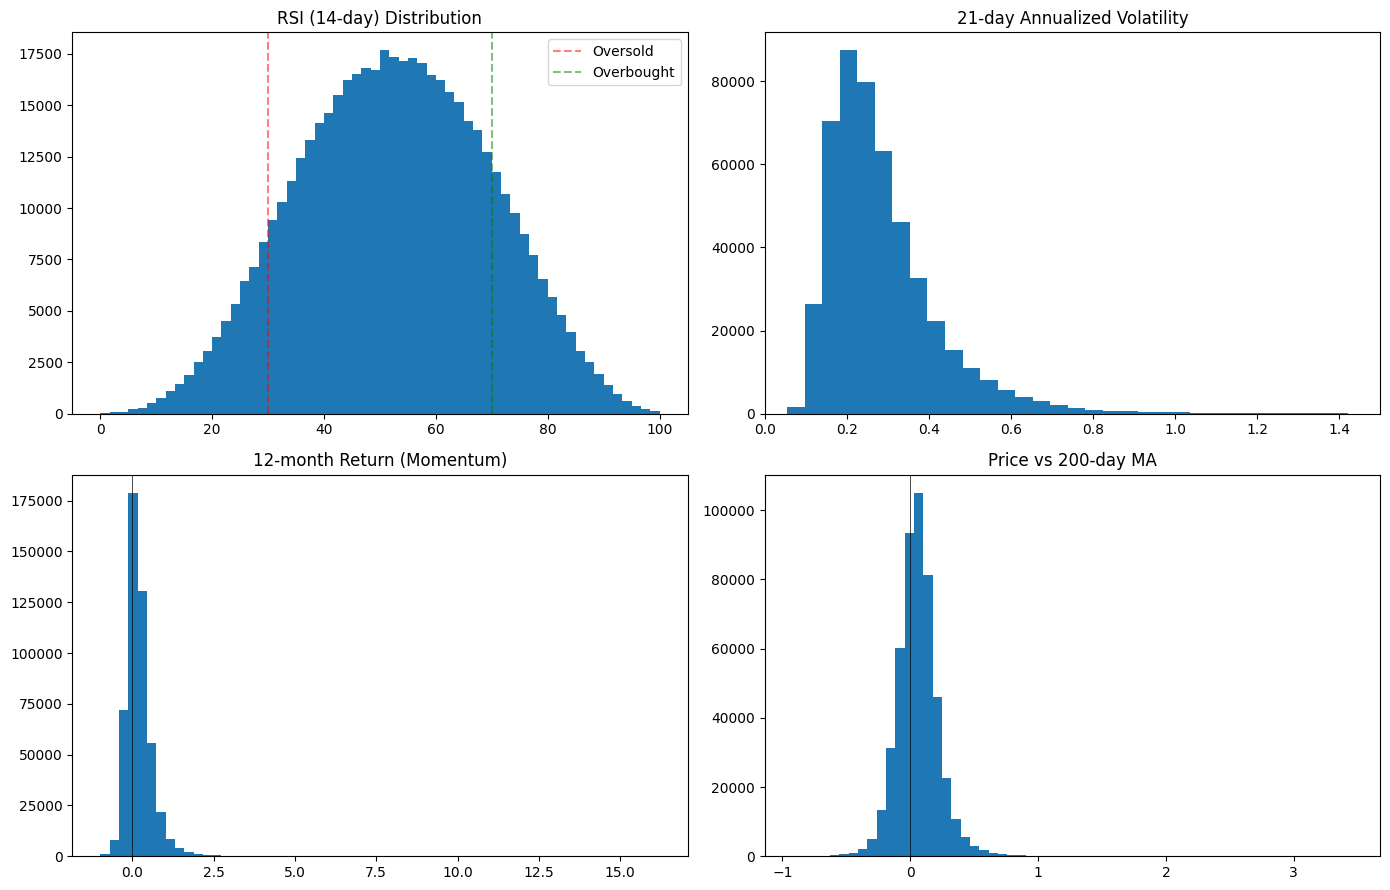

In [2]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

axes[0, 0].hist(df['rsi_14'].dropna(), bins=60)
axes[0, 0].set_title("RSI (14-day) Distribution")
axes[0, 0].axvline(30, color='red', linestyle='--', alpha=0.5, label='Oversold')
axes[0, 0].axvline(70, color='green', linestyle='--', alpha=0.5, label='Overbought')
axes[0, 0].legend()

axes[0, 1].hist(df['volatility_21d'].dropna(), bins=60)
axes[0, 1].set_title("21-day Annualized Volatility")
axes[0, 1].set_xlim(0, 1.5)

axes[1, 0].hist(df['return_252d'].dropna(), bins=60)
axes[1, 0].set_title("12-month Return (Momentum)")
axes[1, 0].axvline(0, color='black', linewidth=0.5)

axes[1, 1].hist(df['price_vs_sma200'].dropna(), bins=60)
axes[1, 1].set_title("Price vs 200-day MA")
axes[1, 1].axvline(0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()

In [3]:
# For each feature, compare its average value for "top quintile next month" vs "rest"
features_to_check = [
    'return_21d', 'return_63d', 'return_252d',
    'rsi_14', 'volatility_21d', 'price_vs_sma50',
    'price_vs_sma200', 'bb_position', 'volume_ratio_20d'
]

comparison = df.groupby('target')[features_to_check].mean().T
comparison.columns = ['Class 0 (rest)', 'Class 1 (top quintile)']
comparison['Difference'] = comparison['Class 1 (top quintile)'] - comparison['Class 0 (rest)']
print("=== Average feature value by target class ===")
print(comparison.round(4))

=== Average feature value by target class ===
                  Class 0 (rest)  Class 1 (top quintile)  Difference
return_21d                0.0143                  0.0132     -0.0011
return_63d                0.0441                  0.0452      0.0011
return_252d               0.2002                  0.2436      0.0434
rsi_14                   52.7220                 52.2273     -0.4947
volatility_21d            0.2820                  0.3191      0.0371
price_vs_sma50            0.0139                  0.0112     -0.0027
price_vs_sma200           0.0587                  0.0607      0.0019
bb_position               0.5443                  0.5327     -0.0116
volume_ratio_20d          1.0092                  1.0183      0.0091


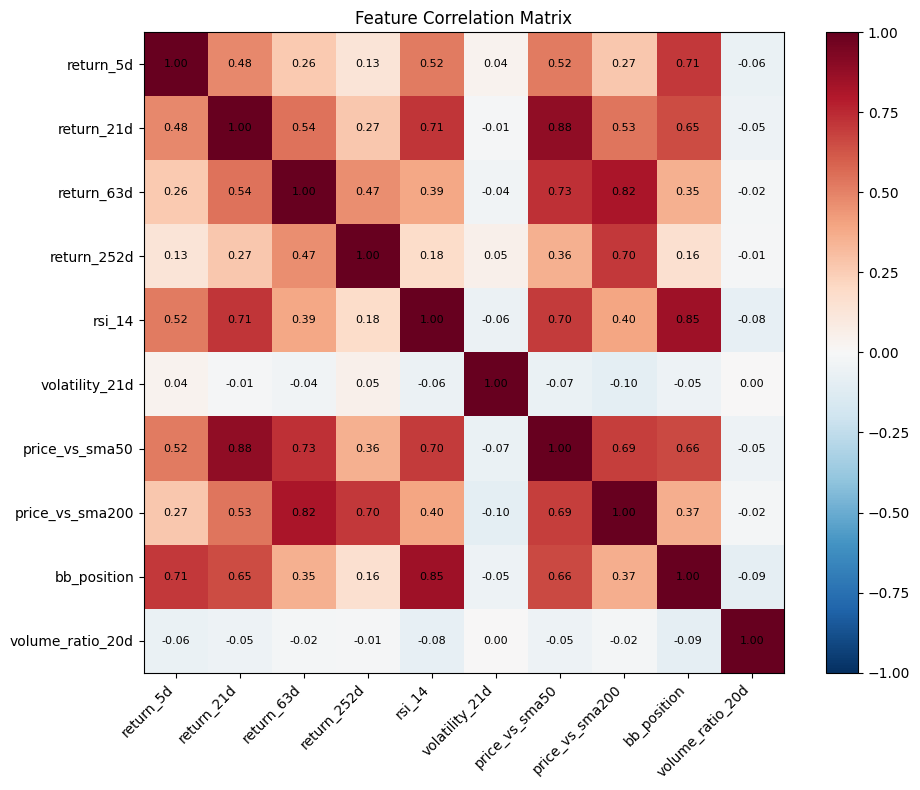

In [4]:
import matplotlib.pyplot as plt

corr_features = ['return_5d', 'return_21d', 'return_63d', 'return_252d',
                 'rsi_14', 'volatility_21d', 'price_vs_sma50',
                 'price_vs_sma200', 'bb_position', 'volume_ratio_20d']

corr = df[corr_features].corr()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr)))
ax.set_yticks(range(len(corr)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticklabels(corr.columns)

for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=8)

plt.colorbar(im, ax=ax)
ax.set_title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

In [5]:
# At any given date, every feature should only use info from that date or earlier
# Pick a random row and verify
sample = df.sample(1).iloc[0]
print(f"Date: {sample['date']}")
print(f"Ticker: {sample['ticker']}")
print(f"Close: {sample['close']:.2f}")
print(f"21-day return: {sample['return_21d']:.4f}  (uses data from {sample['date']} and 21 days back — OK)")
print(f"Forward 21-day return: {sample['forward_return_21d']:.4f}  (uses data from 21 days AFTER {sample['date']} — OK as TARGET)")

Date: 2023-10-27 00:00:00
Ticker: ACN
Close: 279.07
21-day return: -0.0317  (uses data from 2023-10-27 00:00:00 and 21 days back — OK)
Forward 21-day return: 0.1466  (uses data from 21 days AFTER 2023-10-27 00:00:00 — OK as TARGET)
